In [1]:
# Setup (Set working directory, paths, and random seeds)
# Load modules
import os                    # working directory 
import subprocess            # git clone
import sys                   # check Colab
from pathlib import Path     # paths

# Set working directory (w/ git clone)
IN_COLAB = 'google.colab' in sys.modules or Path('/content').exists()

if IN_COLAB:
    ROOT = Path('/content/dl_practice')
    if not ROOT.exists(): 
        subprocess.run(['git', 'clone', 'https://github.com/seungyong0223/dl_practice', str(ROOT) ])
    os.chdir(ROOT)
else:
    if '__file__' in dir(): 
        ROOT = Path(__file__).resolve().parents[1]
    else: 
        ROOT = Path.cwd()
    os.chdir(ROOT)
    
print(f"Working directory is {ROOT}")

# Define paths 
DATA_DIR = ROOT / "data"
CKPT_DIR = ROOT / "checkpoints"
OUTPUT_DIR = ROOT / "outputs"

for d in [DATA_DIR, CKPT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
# Set random seeds 
SEED = 1

import random
import numpy as np 
import torch 

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Check CPU/GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current Device is {device}")


Working directory is /content/dl_practice
Current Device is cuda


In [2]:
# Load modules 

import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

In [3]:
# Download data 
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 7.99MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.3MB/s]


<class 'torchvision.datasets.mnist.FashionMNIST'>
60000
<class 'tuple'>


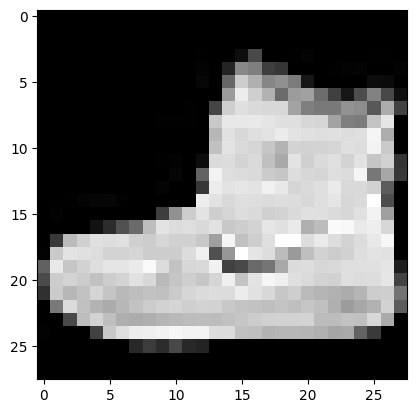

In [43]:
# Explore data 

print(type(training_data))    # class FashionMNIST
print(len(training_data))     # n = 60,000

sample = training_data[0]     # sample 1 
print(type(sample))
# print(sample)

img = training_data[0][0]
label = training_data[0][1]

img.dtype
img.shape

plt.imshow(img.squeeze(), cmap='gray')
plt.show()


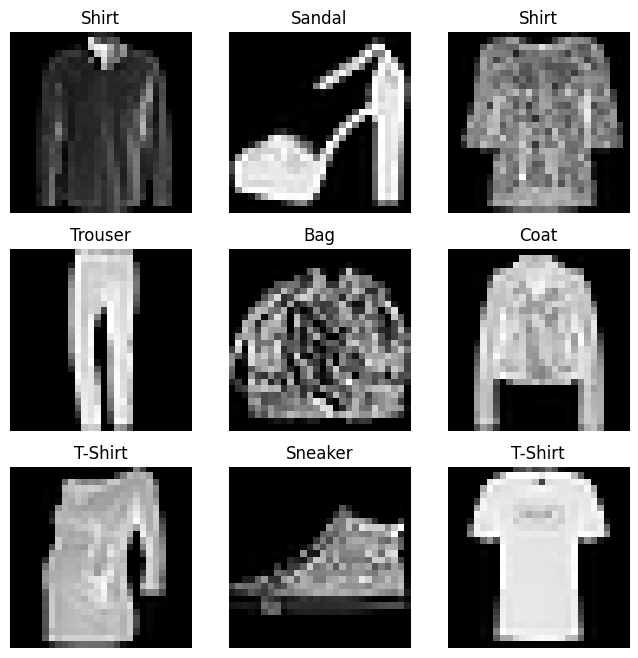

In [65]:
# To fix randomness
# SEED = 1
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED) <---
# torch.cuda.manual_seed_all(SEED)

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [66]:
# Create a custom dataset 
# __init__, __len__, __getitem__ 

import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label